## Soal 2 — EDA Dataset Project

> ⚠️ **DATA CONTOH.** Sel di bawah membangkitkan dataset sintetis (profil skill mahasiswa dan posting proyek) untuk mensimulasikan struktur data ProjectMatch AI, karena dataset asli belum dibuat di notebook ini.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(42)

skill_pool = ['python', 'javascript', 'react', 'nodejs', 'nextjs', 'sql',
              'machine learning', 'deep learning', 'nlp', 'computer vision',
              'flutter', 'android', 'figma', 'ui ux design', 'laravel',
              'php', 'docker', 'devops', 'data analysis', 'tableau',
              'golang', 'cyber security', 'iot', 'arduino', 'game development']

prodi_pool = ['D3 Teknik Informatika', 'S1 Informatika', 'S1 Sistem Informasi',
              'D3 Manajemen Informatika']

def buat_teks_skill(n_skill, tulis_kosong=False, tulis_duplikat=False):
    if tulis_kosong:
        return ''
    skills = list(rng.choice(skill_pool, size=n_skill, replace=False))
    if tulis_duplikat:
        skills = skills + [skills[0]]
    # variasi penulisan acak (huruf besar/kecil, spasi ganda)
    if rng.random() < 0.3:
        skills = [s.upper() for s in skills]
    return ', '.join(skills)

n_mhs = 40
df_mhs = pd.DataFrame({
    'id_mahasiswa': [f'MHS{i:03d}' for i in range(1, n_mhs + 1)],
    'program_studi': rng.choice(prodi_pool, size=n_mhs),
    'angkatan': rng.choice([2022, 2023, 2024, 2025], size=n_mhs),
    'jumlah_repo_github': rng.integers(0, 25, size=n_mhs),
    'skill_teks': [buat_teks_skill(rng.integers(2, 6),
                                    tulis_kosong=(i in [7, 22]),
                                    tulis_duplikat=(i in [3, 15]))
                   for i in range(n_mhs)],
})
# selipkan baris duplikat persis (kesalahan input ganda)
df_mhs = pd.concat([df_mhs, df_mhs.iloc[[5]]], ignore_index=True)

kategori_pool = ['Web Development', 'Mobile Development', 'Data Science',
                  'UI/UX', 'IoT', 'Cyber Security', 'Game Development']

n_proyek = 18
df_proyek = pd.DataFrame({
    'id_proyek': [f'PRJ{i:03d}' for i in range(1, n_proyek + 1)],
    'kategori': rng.choice(kategori_pool, size=n_proyek),
    'pengaju': rng.choice(['Mitra Industri', 'Dosen'], size=n_proyek),
    'kebutuhan_skill_teks': [buat_teks_skill(rng.integers(3, 6),
                                              tulis_kosong=(i == 10))
                              for i in range(n_proyek)],
})

print('Ukuran df_mhs  :', df_mhs.shape)
print('Ukuran df_proyek:', df_proyek.shape)
df_mhs.head()

Ukuran df_mhs  : (41, 5)
Ukuran df_proyek: (18, 4)


,id_mahasiswa,program_studi,angkatan,jumlah_repo_github,skill_teks
0,MHS001,D3 Teknik Informatika,2022,23,"php, arduino, android"
1,MHS002,D3 Manajemen Informatika,2025,10,"IOT, UI UX DESIGN, REACT, ARDUINO"
2,MHS003,S1 Sistem Informasi,2024,4,"arduino, sql, flutter"
3,MHS004,S1 Informatika,2023,20,"GOLANG, SQL, GOLANG"
4,MHS005,S1 Informatika,2022,15,"machine learning, computer vision, ui ux desig..."


In [3]:
df_proyek.head()

,id_proyek,kategori,pengaju,kebutuhan_skill_teks
0,PRJ001,Web Development,Mitra Industri,"ARDUINO, CYBER SECURITY, LARAVEL"
1,PRJ002,Game Development,Dosen,"SQL, ARDUINO, DATA ANALYSIS"
2,PRJ003,Mobile Development,Mitra Industri,"FLUTTER, UI UX DESIGN, NODEJS, NLP, JAVASCRIPT"
3,PRJ004,IoT,Mitra Industri,"DEEP LEARNING, ARDUINO, UI UX DESIGN, TABLEAU,..."
4,PRJ005,Mobile Development,Mitra Industri,"javascript, tableau, nextjs, game development,..."


In [4]:
print('=== df_mhs ===')
df_mhs.info()
print('\nMissing value per kolom:')
print(df_mhs.isnull().sum())
print('\nSkill kosong (string kosong):', (df_mhs['skill_teks'] == '').sum())
print('Baris duplikat penuh:', df_mhs.duplicated().sum())
print('Duplikat berdasarkan id_mahasiswa:', df_mhs.duplicated(subset='id_mahasiswa').sum())

print('\n=== df_proyek ===')
df_proyek.info()
print('\nMissing value per kolom:')
print(df_proyek.isnull().sum())
print('Kebutuhan skill kosong:', (df_proyek['kebutuhan_skill_teks'] == '').sum())

=== df_mhs ===
<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id_mahasiswa        41 non-null     str  
 1   program_studi       41 non-null     str  
 2   angkatan            41 non-null     int64
 3   jumlah_repo_github  41 non-null     int64
 4   skill_teks          41 non-null     str  
dtypes: int64(2), str(3)
memory usage: 1.7 KB

Missing value per kolom:
id_mahasiswa          0
program_studi         0
angkatan              0
jumlah_repo_github    0
skill_teks            0
dtype: int64

Skill kosong (string kosong): 2
Baris duplikat penuh: 1
Duplikat berdasarkan id_mahasiswa: 1

=== df_proyek ===
<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   id_proyek             18 non-null     str  
 1   kate

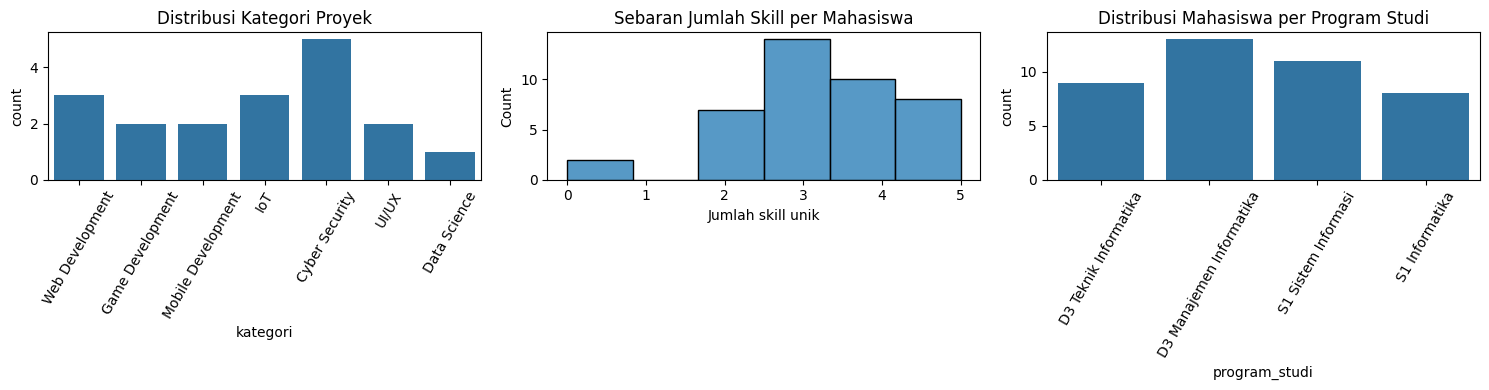

In [5]:
df_mhs['jumlah_skill'] = df_mhs['skill_teks'].apply(
    lambda t: len(set(s.strip().lower() for s in t.split(',') if s.strip())))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df_proyek, x='kategori', ax=ax[0])
ax[0].set_title('Distribusi Kategori Proyek')
ax[0].tick_params(axis='x', rotation=60)

sns.histplot(df_mhs['jumlah_skill'], bins=6, ax=ax[1])
ax[1].set_title('Sebaran Jumlah Skill per Mahasiswa')
ax[1].set_xlabel('Jumlah skill unik')

sns.countplot(data=df_mhs, x='program_studi', ax=ax[2])
ax[2].set_title('Distribusi Mahasiswa per Program Studi')
ax[2].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

**3 insight EDA:**

1. **Ada baris duplikat dan skill kosong** pada `df_mhs` — beberapa mahasiswa tercatat dua kali (kesalahan input/duplikasi submit form), dan beberapa belum mengisi skill sama sekali. Jika dibiarkan, baris kosong akan menghasilkan skor kemiripan 0 ke semua proyek (mahasiswa "hilang" dari rekomendasi), sehingga wajib ditangani sebelum modeling.
2. **Distribusi kategori proyek tidak merata** — beberapa kategori (mis. Web Development) memiliki lebih banyak posting daripada kategori lain (mis. Game Development). Ini berarti hasil *matching* secara alami akan condong merekomendasikan kategori yang lebih ramai, bukan berarti model bias — penting dibedakan saat evaluasi per kategori.
3. **Penulisan skill bervariasi** (huruf besar/kecil, ada yang menulis skill sama dua kali dalam satu profil) — ini mirip masalah `jenis_kelamin` pada Bagian A, dan perlu dinormalisasi (lowercase, dedup) sebelum dijadikan fitur teks, agar TF-IDF tidak menganggap `"Python"` dan `"python"` sebagai dua token berbeda.
4. **Jumlah skill per mahasiswa bervariasi cukup lebar** (ada yang hanya mengisi 2 skill, ada yang sampai 5), yang berpotensi membuat mahasiswa dengan CV lebih "penuh kata kunci" tampak lebih cocok ke banyak proyek — relevan dengan risiko bias yang sudah disinggung pada Soal 1g.